# SpliceAI on CMC (COSMIC Cancer Mutation Census): splice-effect predictions

Same analysis as `spliceai_clinvar_exploration.ipynb`, applied to the CMC somatic mutation set. Loads the full SpliceAI results (`cmc_spliceai_scores_rbp.tsv`, built by `../12_variant_effect_prediction/splicing/`) -- 5,491,494 variants attempted, 5,070,804 scored (92.3%, nearly identical scoring rate to ClinVar's 92.5% -- the unscored fraction is a SpliceAI/annotation limitation, not a pipeline problem, and it's reassuringly consistent between the two independent variant sets).

**Data file is not checked into git** -- regenerate via `12_variant_effect_prediction/splicing/`, or pull `cmc_spliceai_scores_rbp.tsv` from `/u/project/kappel/ddcohn/protein_variant_effects/` on Hoffman2.

Unlike ClinVar, CMC's own source data is coding-mutation-only (see `12_variant_effect_prediction/README.md`), but SpliceAI itself still scores every variant's genomic context regardless -- so this table isn't restricted to exonic-only effects the way DeepLoc/protGPS's input is.

**RBP-only version.** Filtered to the 2,215-gene RNA-binding-protein list in `../12_variant_effect_prediction/rbp_filter/rbp_gene_symbols.txt` (union of a classic-RNA-binding-domain list and RBP2GO's high-confidence human RBP dataset -- see that folder's README for the full method). The genome-wide version of this notebook is `spliceai_cmc_exploration.ipynb`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

SCORE_COLS = ["DS_AG", "DS_AL", "DS_DG", "DS_DL"]
LABELS = ["Acceptor Gain", "Acceptor Loss", "Donor Gain", "Donor Loss"]

## Load data

In [2]:
df = pd.read_csv("cmc_spliceai_scores_rbp.tsv", sep="\t")
print(f"{len(df):,} scored variants")
df.head()

596,266 scored variants


,GENOMIC_MUTATION_ID,DS_AG,DS_AL,DS_DG,DS_DL,DP_AG,DP_AL,DP_DG,DP_DL
0,COSV51273354,0.0,0.0,0.03,0.00,-10,5,2,9
1,COSV51266607,0.0,0.0,0.00,0.00,-36,-27,41,10
2,COSV51293908,0.0,0.0,0.00,0.00,48,-20,-21,47
3,COSV51268352,0.0,0.0,0.01,0.06,19,47,-46,-5
4,COSV51278691,0.0,0.0,0.00,0.00,8,1,42,29


## Delta score distributions

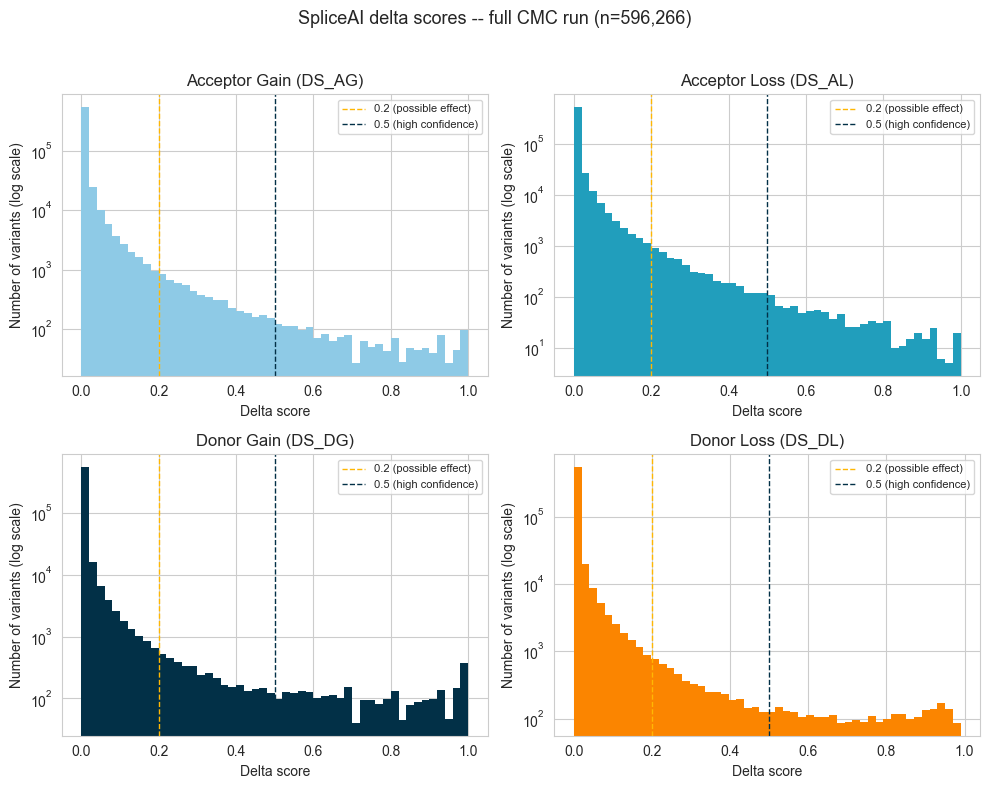

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
panel_colors = ["#8ecae6", "#219ebc", "#023047", "#fb8500"]
for ax, col, label, pcolor in zip(axes.flat, SCORE_COLS, LABELS, panel_colors):
    ax.hist(df[col], bins=50, color=pcolor, edgecolor="none")
    ax.set_yscale("log")
    ax.set_title(f"{label} ({col})")
    ax.set_xlabel("Delta score")
    ax.set_ylabel("Number of variants (log scale)")
    ax.axvline(0.2, color="#ffb703", linestyle="--", linewidth=1, label="0.2 (possible effect)")
    ax.axvline(0.5, color="#023047", linestyle="--", linewidth=1, label="0.5 (high confidence)")
    ax.legend(fontsize=8)
fig.suptitle(f"SpliceAI delta scores -- full CMC run (n={len(df):,})", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Summary counts

In [4]:
max_score = df[SCORE_COLS].max(axis=1)
print(f"Total scored variants: {len(df):,}")
print(f"Max delta score >= 0.2 (possible splicing effect): {(max_score >= 0.2).sum():,} "
      f"({(max_score >= 0.2).mean()*100:.2f}%)")
print(f"Max delta score >= 0.5 (high-confidence effect): {(max_score >= 0.5).sum():,} "
      f"({(max_score >= 0.5).mean()*100:.2f}%)")

Total scored variants: 596,266
Max delta score >= 0.2 (possible splicing effect): 24,626 (4.13%)
Max delta score >= 0.5 (high-confidence effect): 7,543 (1.27%)


## Variants with the strongest predicted splicing effect

In [5]:
top_variants = df.loc[max_score.sort_values(ascending=False).index[:25]]
top_variants[["GENOMIC_MUTATION_ID"] + SCORE_COLS + ["DP_AG", "DP_AL", "DP_DG", "DP_DL"]].head(25)

,GENOMIC_MUTATION_ID,DS_AG,DS_AL,DS_DG,DS_DL,DP_AG,DP_AL,DP_DG,DP_DL
194883,COSV99241864,0.00,0.00,1.0,0.94,-20,6,1,-20
305427,COSV104545950,1.00,0.01,0.0,0.00,2,4,2,40
133312,COSV99866504,0.00,0.00,1.0,0.69,-1,5,-1,28
367460,COSV61432572,0.01,0.00,1.0,0.97,20,39,1,-3
373658,COSV116379146,0.00,0.00,1.0,0.83,49,-45,-2,49
548676,COSV104680020,0.00,0.00,1.0,0.20,2,30,2,-23
32530,COSV69655017,0.90,1.00,0.0,0.00,-20,-1,-22,-20
347779,COSV105067626,0.00,0.00,1.0,0.98,-1,-50,-1,22
101594,COSV115104242,0.00,0.00,1.0,0.77,-1,16,-1,28
371595,COSV50031787,0.00,0.00,1.0,0.01,2,-44,2,-17


## Which splicing mechanism dominates?

For variants with a high-confidence effect (max delta >= 0.5), which of the four delta scores is largest.

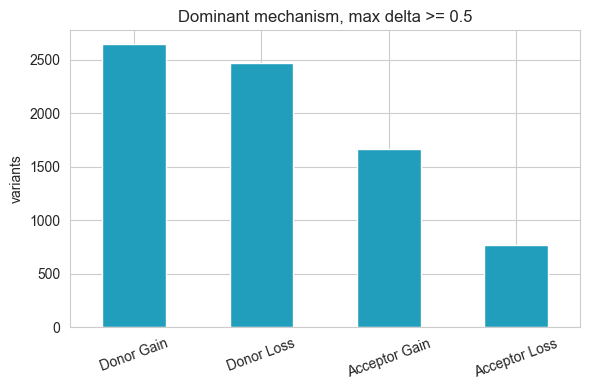

Donor Gain       2643
Donor Loss       2471
Acceptor Gain    1663
Acceptor Loss     766
Name: count, dtype: int64

In [6]:
hi = df[max_score >= 0.5]
mech = hi[SCORE_COLS].idxmax(axis=1).map(dict(zip(SCORE_COLS, LABELS))).value_counts()
mech.plot.bar(color="#219ebc", figsize=(6, 4)); plt.ylabel("variants"); plt.title("Dominant mechanism, max delta >= 0.5")
plt.xticks(rotation=20); plt.tight_layout(); plt.show()
mech

## Where does the predicted splice change occur relative to the variant?

DP is the signed distance in bp from the variant to the affected splice site. High-confidence variants should cluster near the variant (SpliceAI looks +/- 50 bp).

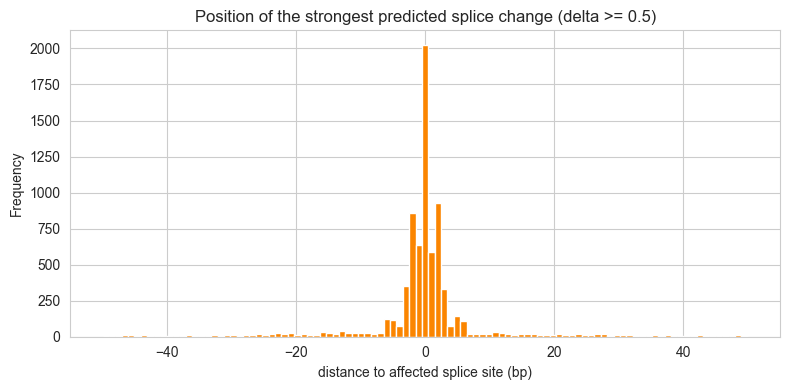

Within 2 bp of the variant: 66.7%


In [7]:
dp_cols = ["DP_AG", "DP_AL", "DP_DG", "DP_DL"]
best = hi[SCORE_COLS].values.argmax(axis=1)
dist = pd.Series([row[i] for row, i in zip(hi[dp_cols].values, best)])
dist.plot.hist(bins=101, range=(-50, 50), figsize=(8, 4), color="#fb8500")
plt.xlabel("distance to affected splice site (bp)"); plt.title("Position of the strongest predicted splice change (delta >= 0.5)"); plt.tight_layout(); plt.show()
print(f"Within 2 bp of the variant: {(dist.abs() <= 2).mean():.1%}")

## Which genes carry the most high-confidence splice-altering variants?

Somatic hotspots matter more than raw counts, so this joins gene names and variant class from the DeepLoc table (`cmc_deeploc_deltas_rbp.tsv`, protein-level variants only, so variants without a built protein sequence such as frameshifts are not annotated here).

In [8]:
ann = pd.read_csv("cmc_deeploc_deltas_rbp.tsv", sep="\t",
                  usecols=["GENOMIC_MUTATION_ID", "GENE_NAME", "category", "label_changed"] + [f"DELTA_{c}" for c in
                  ["Cytoplasm", "Nucleus", "Extracellular", "Cell membrane", "Mitochondrion", "Plastid",
                   "Endoplasmic reticulum", "Lysosome/Vacuole", "Golgi apparatus", "Peroxisome"]])
ann = ann.drop_duplicates("GENOMIC_MUTATION_ID")
df["max_splice"] = max_score
m = df.merge(ann, on="GENOMIC_MUTATION_ID", how="inner")
print(f"{len(m):,} of {len(df):,} scored variants have gene / protein-effect annotation")
m[m["max_splice"] >= 0.5]["GENE_NAME"].value_counts().head(20)

463,244 of 596,266 scored variants have gene / protein-effect annotation


GENE_NAME
KMT2D      63
KMT2C      41
MDN1       33
DMD        31
SYNE2      30
CREBBP     28
HUWE1      28
ATRX       26
POLE       25
DST        24
CNOT1      24
AKAP9      23
POLD1      23
SMARCA4    21
KMT2B      20
TRRAP      20
HFM1       20
MACF1      19
KMT2A      19
ASCC3      18
Name: count, dtype: int64

## Splice effect by protein-level variant class

Fraction of each class with a possible (>= 0.2) or high-confidence (>= 0.5) splice effect. Missense and synonymous-like changes near exon boundaries can act through splicing rather than through the amino-acid change.

In [9]:
m.groupby("category")["max_splice"].agg(n="size", frac_ge_0_2=lambda x: (x >= 0.2).mean(), frac_ge_0_5=lambda x: (x >= 0.5).mean())

,n,frac_ge_0_2,frac_ge_0_5
category,,,
del,1,0.000000,0.000000
ins,1,0.000000,0.000000
missense,429264,0.037441,0.011799
nonsense,33978,0.107334,0.027871


## Combining tools: splicing vs. localization

Variants where SpliceAI predicts a high-confidence splice effect and DeepLoc also predicts a localization shift are candidates where two mechanisms may act together. Note that DeepLoc scores the *unspliced* protein change, so a variant that truly disrupts splicing may not produce that protein at all -- the overlap is a flag for follow-up, not a confirmed double effect.

In [10]:
dl = [c for c in m.columns if c.startswith("DELTA_")]
m["max_loc_delta"] = m[dl].abs().max(axis=1)
both = m[(m["max_splice"] >= 0.5) & (m["max_loc_delta"] >= 0.5)]
print(f"High splice (>=0.5): {(m['max_splice'] >= 0.5).sum():,}")
print(f"High localization shift (>=0.5): {(m['max_loc_delta'] >= 0.5).sum():,}")
print(f"Both: {len(both):,}")
ct = pd.crosstab(m["max_splice"] >= 0.5, m["max_loc_delta"] >= 0.5, rownames=["splice>=0.5"], colnames=["loc>=0.5"])
print(ct)
both.sort_values("max_splice", ascending=False)[["GENOMIC_MUTATION_ID", "GENE_NAME", "category", "max_splice", "max_loc_delta"]].head(20)

High splice (>=0.5): 6,012
High localization shift (>=0.5): 4,589
Both: 87
loc>=0.5      False  True 
splice>=0.5               
False        452730   4502
True           5925     87


,GENOMIC_MUTATION_ID,GENE_NAME,category,max_splice,max_loc_delta
316005,COSV104405857,IARS2,missense,1.00,0.8744
263342,COSV55405650,SRBD1,missense,1.00,0.7397
263177,COSV55398439,SRBD1,missense,1.00,0.6195
154823,COSV108807096,TTC14,nonsense,0.99,0.5460
135567,COSV106490445,SYNE2,nonsense,0.99,0.5311
265661,COSV52591959,CPEB2,nonsense,0.98,0.6488
263178,COSV99765517,SRBD1,missense,0.98,0.6174
263360,COSV99764758,SRBD1,missense,0.98,0.7337
374912,COSV101524158,SRPRB,nonsense,0.97,0.5977
270906,COSV99677098,PPP6R3,missense,0.96,0.9087
